In [1]:
!pip install numpy matplotlib scipy -q

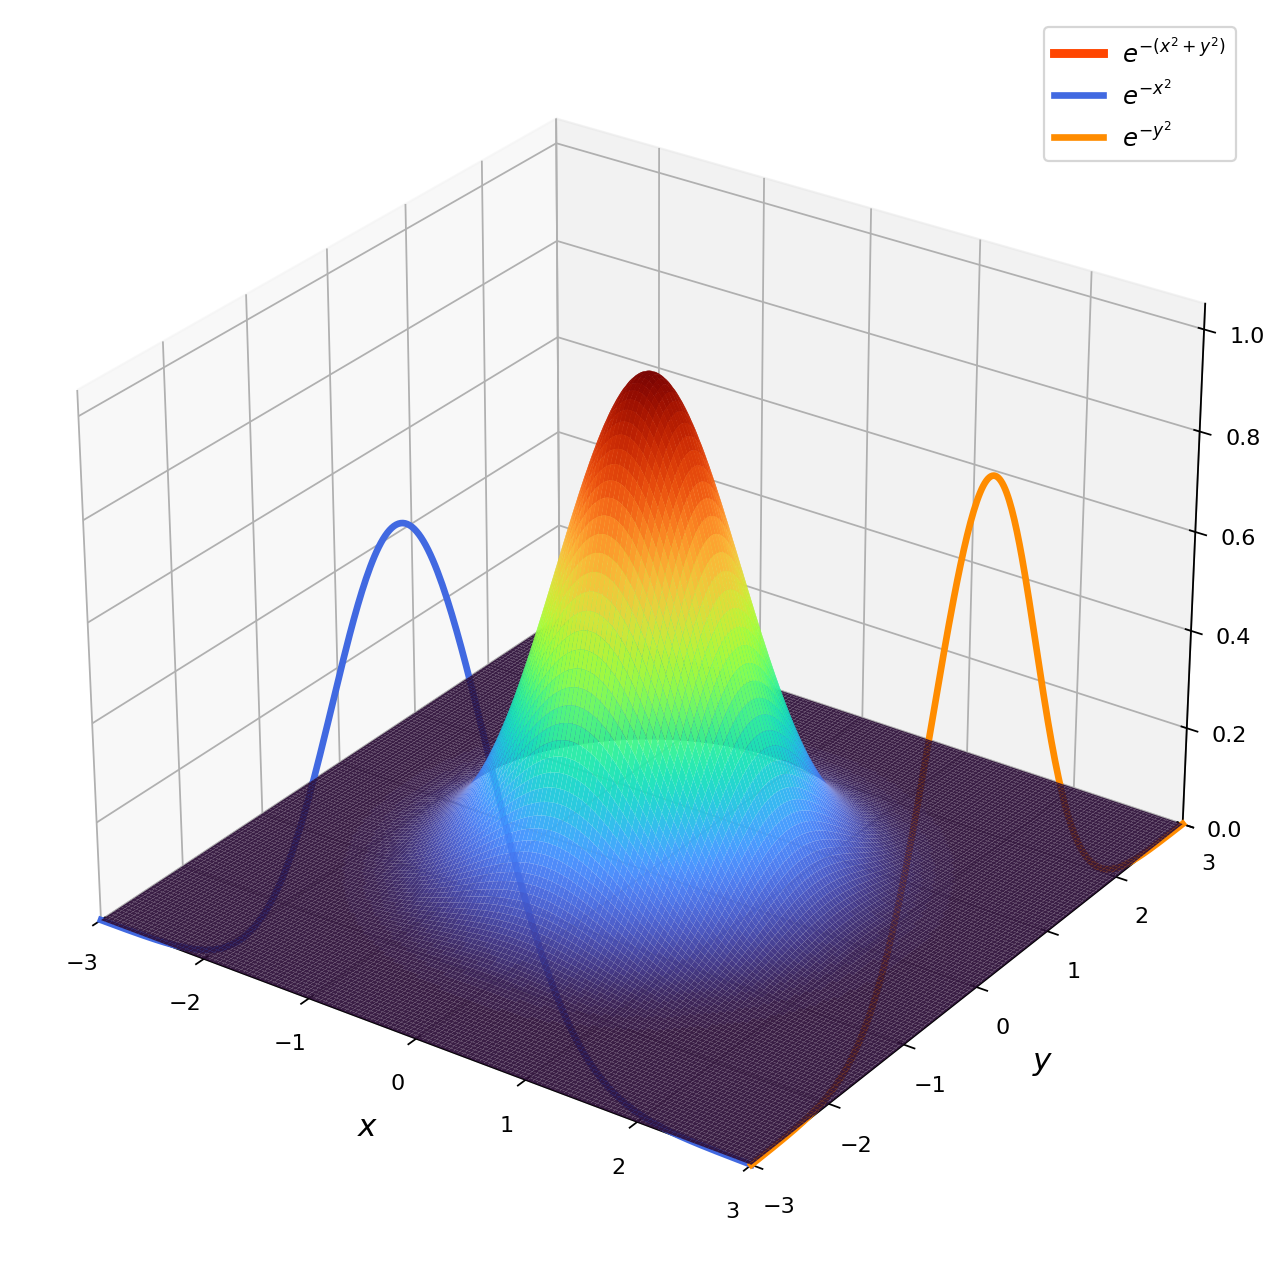

Kaydedildi: gaussian_surface_only.png


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D  # 3D projection için gerekli

# --------------------------------------------------
# 1) Veri oluştur
# --------------------------------------------------
x = np.linspace(-3, 3, 300)
y = np.linspace(-3, 3, 300)
X, Y = np.meshgrid(x, y)

# 2D Gaussian yüzeyi
Z = np.exp(-(X**2 + Y**2))

# 1D Gaussian kesitleri
gx = np.exp(-x**2)   # e^{-x^2}
gy = np.exp(-y**2)   # e^{-y^2}

# --------------------------------------------------
# 2) Figure oluştur
# --------------------------------------------------
fig = plt.figure(figsize=(12, 8), dpi=160)
ax = fig.add_subplot(111, projection='3d')

# --------------------------------------------------
# 3) Ana yüzey: e^{-(x^2+y^2)}
# --------------------------------------------------
surf = ax.plot_surface(
    X, Y, Z,
    cmap='turbo',
    edgecolor='none',
    alpha=0.95,
    rstride=2,
    cstride=2
)

# --------------------------------------------------
# 4) x-kesiti: y = -3 kenarında mavi eğri
#    (görselde soldaki eğri gibi)
# --------------------------------------------------
ax.plot(
    x,                      # x ekseni boyunca
    np.full_like(x, -3),   # y sabit = -3
    gx,                    # z = e^{-x^2}
    color='royalblue',
    linewidth=3
)

# --------------------------------------------------
# 5) y-kesiti: x = +3 kenarında turuncu eğri
#    (görselde sağdaki eğri gibi)
# --------------------------------------------------
ax.plot(
    np.full_like(y, 3),    # x sabit = 3
    y,                     # y ekseni boyunca
    gy,                    # z = e^{-y^2}
    color='darkorange',
    linewidth=3
)

# --------------------------------------------------
# 6) Eksen ayarları
# --------------------------------------------------
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_zlim(0, 1.05)

ax.set_xlabel(r'$x$', fontsize=14, labelpad=8)
ax.set_ylabel(r'$y$', fontsize=14, labelpad=8)
ax.set_zlabel('', fontsize=12)

# Görüş açısı
ax.view_init(elev=28, azim=-55)

# Grid ve panel görünümü
ax.grid(True)

# --------------------------------------------------
# 7) Legend
# --------------------------------------------------
legend_lines = [
    Line2D([0], [0], color='orangered', lw=4, label=r'$e^{-(x^2+y^2)}$'),
    Line2D([0], [0], color='royalblue', lw=3, label=r'$e^{-x^2}$'),
    Line2D([0], [0], color='darkorange', lw=3, label=r'$e^{-y^2}$')
]
ax.legend(handles=legend_lines, loc='upper right', fontsize=11)

# --------------------------------------------------
# 8) Görseli kaydet
# --------------------------------------------------
plt.tight_layout()
plt.savefig("gaussian_surface_only.png", dpi=300, bbox_inches="tight")
plt.show()

print("Kaydedildi: gaussian_surface_only.png")

# Gaussian Integral Derivation

We want to evaluate the Gaussian integral

I = integral from -infinity to infinity of exp(-x^2) dx

That is,

I = ∫[-∞,∞] e^(-x^2) dx

---

## Step 1 — Define the integral

Let

I = ∫[-∞,∞] e^(-x^2) dx

The function e^(-x^2) does not have an elementary antiderivative, so we do not try to integrate it directly.

Instead, we square the integral.

---

## Step 2 — Square the integral

I^2 = ( ∫[-∞,∞] e^(-x^2) dx ) ( ∫[-∞,∞] e^(-y^2) dy )

Here we introduce a second variable y so that the two integrals can be combined into a double integral.

Thus,

I^2 = ∫[-∞,∞] ∫[-∞,∞] e^(-x^2) e^(-y^2) dx dy

Since exponentials multiply by adding exponents,

e^(-x^2) e^(-y^2) = e^(-(x^2 + y^2))

So,

I^2 = ∫[-∞,∞] ∫[-∞,∞] e^(-(x^2 + y^2)) dx dy

---

## Step 3 — Interpret this as an integral over the entire plane

The double integral

∫[-∞,∞] ∫[-∞,∞] e^(-(x^2 + y^2)) dx dy

covers the entire xy-plane.

So now we transform the problem from Cartesian coordinates (x, y) to polar coordinates (r, θ).

---

## Step 4 — Use polar coordinates

In polar coordinates,

x = r cos(θ)
y = r sin(θ)

Therefore,

x^2 + y^2 = r^2

Also, the area element transforms as

dx dy = r dr dθ

This extra factor r is the Jacobian determinant of the polar coordinate transformation.

So the integral becomes

I^2 = ∫[θ=0 to 2π] ∫[r=0 to ∞] e^(-r^2) r dr dθ

That is,

I^2 = ∫[0,2π] ∫[0,∞] e^(-r^2) r dr dθ

---

## Step 5 — Evaluate the radial integral

Now focus on the inner integral

∫[0,∞] e^(-r^2) r dr

Use the substitution

u = r^2

Differentiate:

du = 2r dr

So,

r dr = (1/2) du

Substitute into the integral:

∫[0,∞] e^(-r^2) r dr
= ∫[0,∞] e^(-u) (1/2) du
= (1/2) ∫[0,∞] e^(-u) du

Now integrate:

∫[0,∞] e^(-u) du = [-e^(-u)] from 0 to ∞ = 1

Therefore,

∫[0,∞] e^(-r^2) r dr = 1/2

---

## Step 6 — Finish the angular integral

Substitute this result back into the expression for I^2:

I^2 = ∫[0,2π] (1/2) dθ

Factor out the constant:

I^2 = (1/2) ∫[0,2π] dθ

Now integrate over θ:

∫[0,2π] dθ = 2π

So,

I^2 = (1/2)(2π) = π

---

## Step 7 — Take the square root

We obtained

I^2 = π

Since the integral I is positive,

I = sqrt(π)

So the final result is

∫[-∞,∞] e^(-x^2) dx = sqrt(π)

---

# Final boxed result

I = ∫[-∞,∞] e^(-x^2) dx = sqrt(π)

---

# Short conceptual summary

1. Start with the Gaussian integral
   I = ∫[-∞,∞] e^(-x^2) dx

2. Square it
   I^2 = (∫ e^(-x^2) dx)(∫ e^(-y^2) dy)

3. Rewrite it as a double integral
   I^2 = ∫∫ e^(-(x^2 + y^2)) dx dy

4. Convert to polar coordinates
   x^2 + y^2 = r^2
   dx dy = r dr dθ

5. Evaluate
   I^2 = ∫[0,2π] ∫[0,∞] e^(-r^2) r dr dθ = π

6. Take the square root
   I = sqrt(π)
